# Markov Chains: From Theory to Practice
## Grid World 3×3: Policy Evaluation in 2D

In this notebook we extend the 1D chain to a **3×3 grid world**. We will:
1. Define a 9-state 2D environment with four actions (up/down/left/right)
2. Demonstrate environment dynamics and policy sampling
3. Simulate full episodes and visualize agent trajectories
4. Implement Value Function (V) and Action-Value Function (Q) updates
5. Run learning and inspect convergence
6. Evaluate the learned policy from random starting positions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

np.random.seed(42)

# ── Grid dimensions ──────────────────────────────────────────────────────────
GRID_H, GRID_W = 3, 3
NUM_STATES = GRID_H * GRID_W          # 9 states, indexed 0-8
GOAL_STATE  = 0                        # top-left corner is the absorbing goal

# ── State ↔ (row, col) helpers ───────────────────────────────────────────────
def state_to_rc(s):
    """Return (row, col) for flat state index s."""
    return divmod(s, GRID_W)

def rc_to_state(r, c):
    """Return flat state index for (row, col)."""
    return r * GRID_W + c

# ── Actions: 0=Up, 1=Down, 2=Left, 3=Right ──────────────────────────────────
ACTIONS    = np.array([0, 1, 2, 3])
ACTION_DR  = np.array([-1, 1,  0, 0])   # row delta
ACTION_DC  = np.array([ 0, 0, -1, 1])   # col delta
ACTION_NAMES = ["Up", "Down", "Left", "Right"]

# ── Rewards: −1 everywhere except goal ───────────────────────────────────────
Rewards = np.full(NUM_STATES, -1.0)
Rewards[GOAL_STATE] = 0.0

# ── Random initial policy (rows sum to 1) ────────────────────────────────────
Policy = np.random.dirichlet(np.ones(len(ACTIONS)), size=NUM_STATES)
Policy[GOAL_STATE] = np.array([1.0, 0.0, 0.0, 0.0])   # goal: always "Up" (stays)

# ── Initial value function ────────────────────────────────────────────────────
V = np.zeros(NUM_STATES)
Q = np.zeros((NUM_STATES, len(ACTIONS)))

print("States and their (row, col) positions:")
for s in range(NUM_STATES):
    r, c = state_to_rc(s)
    marker = " ← GOAL" if s == GOAL_STATE else ""
    print(f"  State {s}: row={r}, col={c}{marker}")

print(f"\nRewards: {Rewards}")
print(f"\nInitial Policy shape: {Policy.shape}  (states × actions)")
print("Initial Policy (each row sums to 1):")
print(Policy.round(3))

States and their (row, col) positions:
  State 0: row=0, col=0 ← GOAL
  State 1: row=0, col=1
  State 2: row=0, col=2
  State 3: row=1, col=0
  State 4: row=1, col=1
  State 5: row=1, col=2
  State 6: row=2, col=0
  State 7: row=2, col=1
  State 8: row=2, col=2

Rewards: [ 0. -1. -1. -1. -1. -1. -1. -1. -1.]

Initial Policy shape: (9, 4)  (states × actions)
Initial Policy (each row sums to 1):
[[1.    0.    0.    0.   ]
 [0.07  0.07  0.025 0.834]
 [0.162 0.217 0.004 0.617]
 [0.736 0.098 0.083 0.083]
 [0.18  0.369 0.28  0.171]
 [0.499 0.079 0.182 0.24 ]
 [0.197 0.497 0.072 0.234]
 [0.434 0.023 0.452 0.09 ]
 [0.008 0.369 0.418 0.205]]


### Environment Dynamics: Step Function

The `step` function implements the 3×3 grid world rules:
- **Goal state (0)** is absorbing — any action keeps the agent there with reward 0
- Actions attempt to move the agent in the chosen direction
- **Walls**: if the move would go out of bounds, the agent stays in place
- **Reward**: −1 for every step from a non-goal state

Grid layout (state indices):

  [0G]  1   2  
   3   4   5  
   6   7   8  

  [0G] = Goal state (absorbing)
  Actions: 0=Up  1=Down  2=Left  3=Right
  Walls:   moving into a wall keeps the agent in place


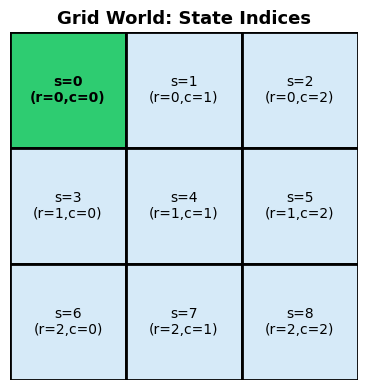


Transition Table: step(state, action) → (next_state, reward)
 State  (r,c)   Action   Next   Reward
------------------------------------------------------------
     0   (0, 0)        Up      0       0.0
     0   (0, 0)      Down      0       0.0
     0   (0, 0)      Left      0       0.0
     0   (0, 0)     Right      0       0.0

     1   (0, 1)        Up      1      -1.0
     1   (0, 1)      Down      4      -1.0
     1   (0, 1)      Left      0      -1.0
     1   (0, 1)     Right      2      -1.0

     2   (0, 2)        Up      2      -1.0
     2   (0, 2)      Down      5      -1.0
     2   (0, 2)      Left      1      -1.0
     2   (0, 2)     Right      2      -1.0

     3   (1, 0)        Up      0      -1.0
     3   (1, 0)      Down      6      -1.0
     3   (1, 0)      Left      3      -1.0
     3   (1, 0)     Right      4      -1.0

     4   (1, 1)        Up      1      -1.0
     4   (1, 1)      Down      7      -1.0
     4   (1, 1)      Left      3      -1.0
     4   (1, 1)  

In [4]:
def step(state, action):
    """
    Execute one step in the 3×3 grid world.

    Args:
        state  : current state (int, 0-8)
        action : action index (0=Up, 1=Down, 2=Left, 3=Right)

    Returns:
        next_state (int), reward (float)
    """
    if state == GOAL_STATE:
        return GOAL_STATE, 0.0

    r, c = state_to_rc(state)
    nr = np.clip(r + ACTION_DR[action], 0, GRID_H - 1)
    nc = np.clip(c + ACTION_DC[action], 0, GRID_W - 1)
    next_state = rc_to_state(int(nr), int(nc))
    return next_state, Rewards[state]


# ── Visualize grid layout ─────────────────────────────────────────────────────
print("Grid layout (state indices):")
print()
grid_display = np.arange(NUM_STATES).reshape(GRID_H, GRID_W)
for r in range(GRID_H):
    row_str = ""
    for c in range(GRID_W):
        s = grid_display[r, c]
        label = f"[{s}G]" if s == GOAL_STATE else f" {s} "
        row_str += label + " "
    print("  " + row_str)
print()
print("  [0G] = Goal state (absorbing)")
print("  Actions: 0=Up  1=Down  2=Left  3=Right")
print("  Walls:   moving into a wall keeps the agent in place")

# ── Visual grid with matplotlib ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, GRID_W)
ax.set_ylim(0, GRID_H)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Grid World: State Indices", fontsize=13, fontweight='bold')

for s in range(NUM_STATES):
    r, c = state_to_rc(s)
    # flip row so row 0 appears at top
    row_plot = GRID_H - 1 - r
    color = '#2ecc71' if s == GOAL_STATE else '#d6eaf8'
    rect = plt.Rectangle((c, row_plot), 1, 1,
                          linewidth=2, edgecolor='black', facecolor=color)
    ax.add_patch(rect)
    label = f"s={s}\n(r={r},c={c})"
    ax.text(c + 0.5, row_plot + 0.5, label,
            ha='center', va='center', fontsize=10,
            fontweight='bold' if s == GOAL_STATE else 'normal')

plt.tight_layout()
plt.show()

# ── Transition table ──────────────────────────────────────────────────────────
print("\nTransition Table: step(state, action) → (next_state, reward)")
print("=" * 60)
print(f"{'State':>6} {'(r,c)':>6} {'Action':>8} {'Next':>6} {'Reward':>8}")
print("-" * 60)
for s in range(NUM_STATES):
    for a in ACTIONS:
        ns, rew = step(s, a)
        rc = state_to_rc(s)
        print(f"  {s:>4}   {str(rc):>6}  {ACTION_NAMES[a]:>8}  {ns:>5}  {rew:>8.1f}")
    print()

### Policy Representation and Action Sampling

The policy is a matrix of shape `(NUM_STATES, NUM_ACTIONS)`:
- Each row is a probability distribution over actions for that state
- `Policy[s, a]` = probability of taking action `a` in state `s`

The `sample_action` function draws one action according to this distribution.
We verify empirically that sampled frequencies match the policy probabilities.

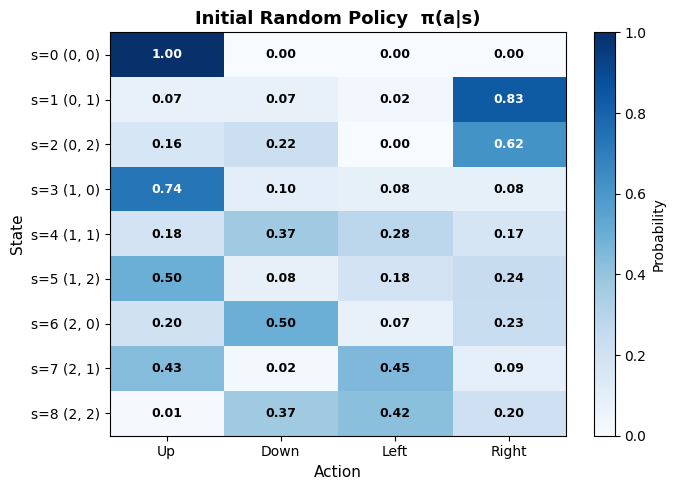

Verification: empirical action frequencies vs policy probabilities
(100 000 samples per state)
State 0:
      Up: policy=1.0000  empirical=1.0000  diff=0.00000
    Down: policy=0.0000  empirical=0.0000  diff=0.00000
    Left: policy=0.0000  empirical=0.0000  diff=0.00000
   Right: policy=0.0000  empirical=0.0000  diff=0.00000
State 1:
      Up: policy=0.0704  empirical=0.0698  diff=0.00059
    Down: policy=0.0704  empirical=0.0694  diff=0.00099
    Left: policy=0.0248  empirical=0.0256  diff=0.00073
   Right: policy=0.8344  empirical=0.8353  diff=0.00085
State 2:
      Up: policy=0.1620  empirical=0.1613  diff=0.00068
    Down: policy=0.2170  empirical=0.2168  diff=0.00015
    Left: policy=0.0037  empirical=0.0036  diff=0.00008
   Right: policy=0.6174  empirical=0.6183  diff=0.00091
State 3:
      Up: policy=0.7356  empirical=0.7359  diff=0.00029
    Down: policy=0.0983  empirical=0.0993  diff=0.00100
    Left: policy=0.0826  empirical=0.0810  diff=0.00161
   Right: policy=0.0834  empi

In [5]:
def sample_action(state, policy):
    """
    Sample an action according to the policy for a given state.

    Args:
        state  : current state (int, 0-8)
        policy : array of shape (NUM_STATES, NUM_ACTIONS)

    Returns:
        action index (int, 0-3)
    """
    return int(np.random.choice(ACTIONS, p=policy[state]))


# ── Visualize initial random policy as heatmap ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(Policy, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_title("Initial Random Policy  π(a|s)", fontsize=13, fontweight='bold')
ax.set_xlabel("Action", fontsize=11)
ax.set_ylabel("State", fontsize=11)
ax.set_xticks(range(len(ACTIONS)))
ax.set_xticklabels(ACTION_NAMES)
ax.set_yticks(range(NUM_STATES))
ax.set_yticklabels([f"s={s} {state_to_rc(s)}" for s in range(NUM_STATES)])
plt.colorbar(im, label='Probability')

for s in range(NUM_STATES):
    for a in ACTIONS:
        prob = Policy[s, a]
        color = 'white' if prob > 0.6 else 'black'
        ax.text(a, s, f"{prob:.2f}", ha='center', va='center',
                fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.show()


# ── Empirical verification ────────────────────────────────────────────────────
print("Verification: empirical action frequencies vs policy probabilities")
print("(100 000 samples per state)")
print("=" * 70)

NUM_SAMPLES = 100_000
max_diff = 0.0

for s in range(NUM_STATES):
    counts = np.zeros(len(ACTIONS))
    for _ in range(NUM_SAMPLES):
        counts[sample_action(s, Policy)] += 1
    empirical = counts / NUM_SAMPLES
    diffs = np.abs(empirical - Policy[s])
    max_diff = max(max_diff, diffs.max())
    print(f"State {s}:")
    for a in ACTIONS:
        print(f"  {ACTION_NAMES[a]:>6}: policy={Policy[s,a]:.4f}  "
              f"empirical={empirical[a]:.4f}  diff={diffs[a]:.5f}")

print(f"\nMax difference across all states/actions: {max_diff:.5f}")
print("✓ Sampling matches policy distribution")

### Episode Simulation: Running One Full Trajectory

The `run_episode` function executes a complete episode from a given starting state
until the agent reaches the goal (state 0).

At each step:
1. Sample an action according to the current policy
2. Execute the action via `step`
3. Record the resulting state and reward
4. Stop when the agent reaches the goal state

We also implement `plot_trajectory` to visualize the agent's path on the grid.

Example episodes from every non-goal starting state
Start=1  steps= 95  total_reward= -95  path=[1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 5, 2, 2, 2, 2, 2, 2, 2, 2, 5, 2, 2, 2, 2, 2, 5, 2, 5, 2, 2, 2, 2, 2, 5, 2, 2, 5, 2, 5, 2, 2, 2, 2, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 2, 5, 2, 5, 2, 2, 2, 2, 5, 8, 8, 7, 8, 8, 7, 4, 3, 0]
Start=2  steps= 39  total_reward= -39  path=[2, 5, 4, 1, 2, 2, 2, 5, 4, 5, 2, 2, 2, 2, 5, 5, 2, 2, 2, 5, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 4, 7, 6, 6, 3, 0]
Start=3  steps=  1  total_reward=  -1  path=[3, 0]
Start=4  steps=  2  total_reward=  -2  path=[4, 3, 0]
Start=5  steps=  3  total_reward=  -3  path=[5, 4, 3, 0]
Start=6  steps= 44  total_reward= -44  path=[6, 7, 4, 7, 6, 7, 6, 3, 4, 3, 4, 1, 2, 5, 4, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 4, 1, 2, 2, 5, 2, 2, 5, 2, 2, 2, 2, 5, 4, 3, 0]
Start=7  steps= 12  total_reward= -12  path=[7, 8, 7, 6, 6, 6, 6, 6, 6, 3, 4, 3, 0]
Start=8  steps=  7  tota

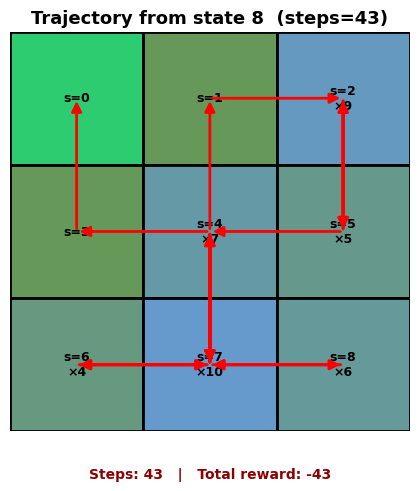

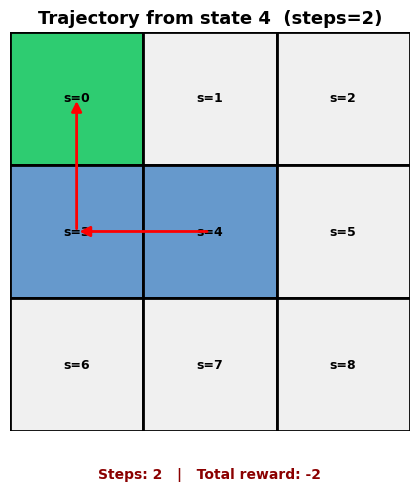

In [44]:
np.random.seed(0)

def run_episode(start_state, policy, max_steps=1000):
    """
    Run one episode from start_state following policy until goal is reached.

    Args:
        start_state : initial state (int, 0-8)
        policy      : array of shape (NUM_STATES, NUM_ACTIONS)
        max_steps   : safety limit to prevent infinite loops

    Returns:
        state_history  : list of visited states (ends with GOAL_STATE)
        reward_history : list of rewards received at each step
    """
    state = int(start_state)
    state_history  = [state]
    reward_history = []

    for _ in range(max_steps):
        if state == GOAL_STATE:
            break
        action = sample_action(state, policy)
        next_state, reward = step(state, action)
        state_history.append(next_state)
        reward_history.append(reward)
        state = next_state

    return state_history, reward_history


def plot_trajectory(state_history, title="Agent Trajectory"):
    """
    Visualize one episode trajectory on the 3×3 grid.

    Each visited cell is shaded by visit order (darker = visited later).
    Arrows show the direction of each move.
    """
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlim(0, GRID_W)
    ax.set_ylim(0, GRID_H)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

    # count visits per state for shading
    visit_count = np.zeros(NUM_STATES)
    for s in state_history:
        visit_count[s] += 1
    max_visits = max(visit_count.max(), 1)

    # draw grid cells
    for s in range(NUM_STATES):
        r, c = state_to_rc(s)
        row_plot = GRID_H - 1 - r
        if s == GOAL_STATE:
            color = '#2ecc71'
        elif visit_count[s] > 0:
            intensity = 0.3 + 0.5 * (visit_count[s] / max_visits)
            color = (0.4, 0.6, intensity)
        else:
            color = '#f0f0f0'
        rect = plt.Rectangle((c, row_plot), 1, 1,
                              linewidth=2, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        label = f"s={s}" + (f"\n×{int(visit_count[s])}" if visit_count[s] > 1 else "")
        ax.text(c + 0.5, row_plot + 0.5, label,
                ha='center', va='center', fontsize=9, fontweight='bold')

    # draw arrows for each transition
    for i in range(len(state_history) - 1):
        s  = state_history[i]
        ns = state_history[i + 1]
        r0, c0 = state_to_rc(s)
        r1, c1 = state_to_rc(ns)
        # convert to plot coords (center of cell)
        x0 = c0 + 0.5;  y0 = GRID_H - 1 - r0 + 0.5
        x1 = c1 + 0.5;  y1 = GRID_H - 1 - r1 + 0.5
        if (x0, y0) != (x1, y1):   # skip self-loops on walls
            ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle="-|>", color='red',
                                        lw=2, mutation_scale=15))

    # step counter label
    ax.text(GRID_W / 2, -0.35,
            f"Steps: {len(state_history)-1}   |   "
            f"Total reward: {(len(state_history)-1)*(-1)}",
            ha='center', fontsize=10, color='darkred', fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── Demo: run and visualize episodes from each non-goal state ─────────────────
print("Example episodes from every non-goal starting state")
print("=" * 60)

for start in range(1, NUM_STATES):
    sh, rh = run_episode(start, Policy)
    print(f"Start={start}  steps={len(sh)-1:3d}  "
          f"total_reward={sum(rh):4.0f}  "
          f"path={sh}")
    assert sh[-1] == GOAL_STATE, "Episode did not reach goal!"

print("\n✓ All episodes terminated at goal state")

# visualize two example trajectories
for start in [8, 4]:
    sh, rh = run_episode(start, Policy)
    plot_trajectory(sh, title=f"Trajectory from state {start}  "
                               f"(steps={len(sh)-1})")

### Value Function: Iterative Updates (Policy Evaluation)

We estimate **V(s)** — the expected cumulative discounted reward starting from state s
under the current policy — using the Bellman equation:

$$V(s) = r_s + \gamma \sum_{s'} P(s'|s) \cdot V(s')$$

Steps:
1. Build the transition matrix **P** from the current policy and environment dynamics
2. Repeatedly apply the Bellman operator until convergence
3. Track the convergence history for visualization

The contraction mapping theorem guarantees convergence for any γ < 1.

Transition matrix P  (shape: NUM_STATES × NUM_STATES)
P[i, j] = probability of going from state i to state j under policy

[[1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.025 0.07  0.834 0.    0.07  0.    0.    0.    0.   ]
 [0.    0.004 0.779 0.    0.    0.217 0.    0.    0.   ]
 [0.736 0.    0.    0.083 0.083 0.    0.098 0.    0.   ]
 [0.    0.18  0.    0.28  0.    0.171 0.    0.369 0.   ]
 [0.    0.    0.499 0.    0.182 0.24  0.    0.    0.079]
 [0.    0.    0.    0.197 0.    0.    0.569 0.234 0.   ]
 [0.    0.    0.    0.    0.434 0.    0.452 0.023 0.09 ]
 [0.    0.    0.    0.    0.    0.008 0.    0.418 0.574]]


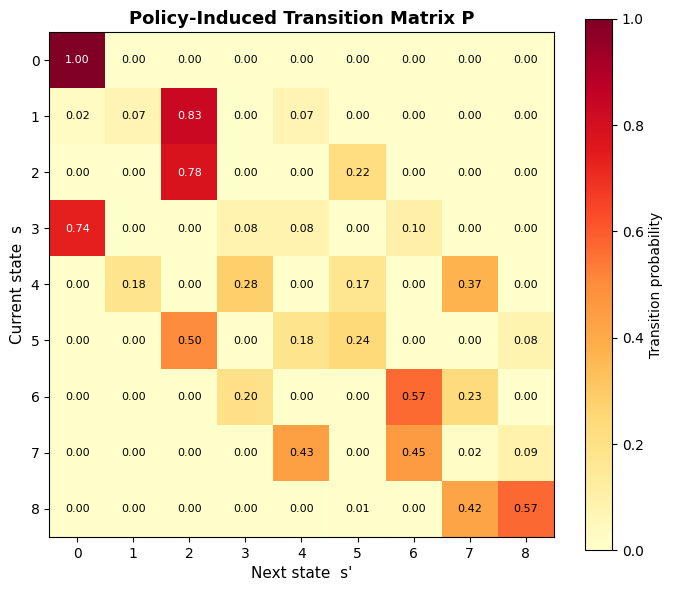

iter   50  |  max_change = 1.73e-01  |  V = [  0.   -25.45 -26.3   -3.75 -15.93 -23.65 -11.76 -14.89 -16.85]
iter  100  |  max_change = 2.22e-02  |  V = [  0.   -28.93 -29.9   -4.04 -17.76 -26.75 -12.76 -16.37 -18.48]
iter  150  |  max_change = 2.86e-03  |  V = [  0.   -29.38 -30.36  -4.07 -18.   -27.15 -12.89 -16.56 -18.69]
iter  200  |  max_change = 3.67e-04  |  V = [  0.   -29.44 -30.42  -4.08 -18.03 -27.2  -12.9  -16.58 -18.71]
iter  250  |  max_change = 4.71e-05  |  V = [  0.   -29.44 -30.43  -4.08 -18.03 -27.21 -12.91 -16.58 -18.72]
iter  300  |  max_change = 6.06e-06  |  V = [  0.   -29.44 -30.43  -4.08 -18.03 -27.21 -12.91 -16.58 -18.72]

Final V* = [  0.    -29.444 -30.429  -4.079 -18.032 -27.206 -12.906 -16.584 -18.718]
✓ Value iteration complete
0 1 2 
3 4 5 
6 7 8 


In [8]:
def build_transition_matrix(policy):
    """
    Build the (NUM_STATES × NUM_STATES) transition matrix
    induced by the given policy and environment dynamics.

    P[s, s'] = Σ_a  π(a|s) · I[step(s,a) = s']
    """
    P = np.zeros((NUM_STATES, NUM_STATES))
    for s in range(NUM_STATES):
        for a in ACTIONS:
            ns, _ = step(s, a)
            P[s, ns] += policy[s, a]
    return P


def value_iteration_step(V, P, rewards, gamma=0.99):
    """
    One synchronous Bellman update for all states.

    V_new(s) = r(s) + γ · P[s, :] · V_old

    Returns:
        V_new      : updated value array
        max_change : ||V_new - V_old||_inf  (convergence metric)
    """
    V_new = rewards + gamma * (P @ V)
    max_change = np.max(np.abs(V_new - V))
    return V_new, max_change


# ── Build theoretical transition matrix ──────────────────────────────────────
P_matrix = build_transition_matrix(Policy)

print("Transition matrix P  (shape: NUM_STATES × NUM_STATES)")
print("P[i, j] = probability of going from state i to state j under policy\n")
print(np.round(P_matrix, 3))

# visualize P
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(P_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_title("Policy-Induced Transition Matrix P", fontsize=13, fontweight='bold')
ax.set_xlabel("Next state  s'", fontsize=11)
ax.set_ylabel("Current state  s", fontsize=11)
ax.set_xticks(range(NUM_STATES))
ax.set_yticks(range(NUM_STATES))
plt.colorbar(im, label='Transition probability')
for i in range(NUM_STATES):
    for j in range(NUM_STATES):
        val = P_matrix[i, j]
        color = 'white' if val > 0.6 else 'black'
        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                fontsize=8, color=color)
plt.tight_layout()
plt.show()

# ── Run value iteration ───────────────────────────────────────────────────────
V = np.zeros(NUM_STATES)
gamma = 0.99
V_history      = [V.copy()]
conv_history   = []

NUM_ITER = 300
for it in range(NUM_ITER):
    
    V, delta = value_iteration_step(V, P_matrix, Rewards, gamma)

    V_history.append(V.copy())
    conv_history.append(delta)
    if (it + 1) % 50 == 0:
        print(f"iter {it+1:4d}  |  max_change = {delta:.2e}  |  "
              f"V = {np.round(V, 2)}")

print(f"\nFinal V* = {np.round(V, 3)}")
print("✓ Value iteration complete")

c = 0
for i in range(3):
    for j in range(3):
        print(c, end=" ")
        c += 1
    print()


### Value Function Heatmap

We visualize the converged value function V*(s) on the 3×3 grid.

- **Greener** cells have higher (less negative) value — closer to the goal
- **Redder** cells have lower (more negative) value — farther from the goal
- Numbers show the exact V*(s) for each state

This gives an intuitive picture of how "desirable" each cell is under the current policy.

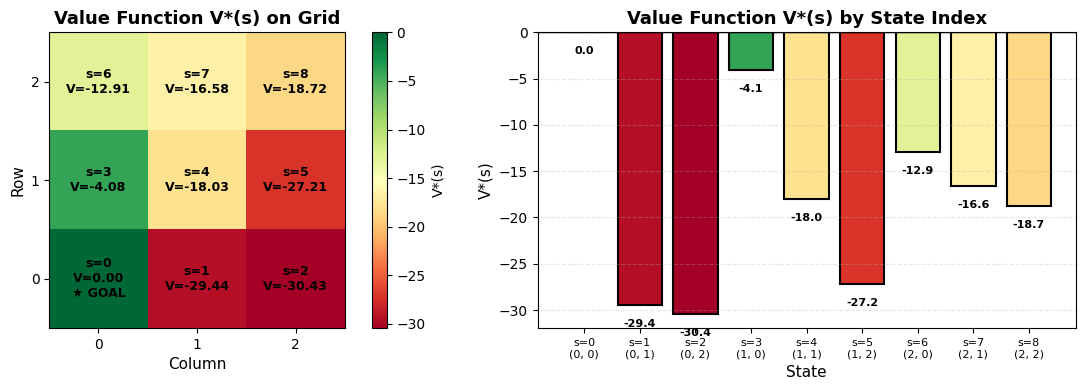

V* summary:
  Best  state: s=0  V=0.000  (0, 0)
  Worst state: s=2  V=-30.429  (0, 2)


In [10]:
# ── Reshape V into grid shape for heatmap ────────────────────────────────────
V_grid = V.reshape(GRID_H, GRID_W)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Plot 1: heatmap on actual grid layout ────────────────────────────────────
ax = axes[0]
# flip rows so row 0 (goal) appears at top-left
im = ax.imshow(V_grid[::-1], cmap='RdYlGn', aspect='equal')
ax.set_title("Value Function V*(s) on Grid", fontsize=13, fontweight='bold')
ax.set_xlabel("Column", fontsize=11)
ax.set_ylabel("Row", fontsize=11)
ax.set_xticks(range(GRID_W))
ax.set_yticks(range(GRID_H))
ax.set_yticklabels(range(GRID_H - 1, -1, -1))   # row labels: 2,1,0 top→bottom
plt.colorbar(im, ax=ax, label='V*(s)')

for s in range(NUM_STATES):
    r, c = state_to_rc(s)
    row_plot = GRID_H - 1 - r
    goal_marker = "\n★ GOAL" if s == GOAL_STATE else ""
    ax.text(c, row_plot,
            f"s={s}\nV={V[s]:.2f}{goal_marker}",
            ha='center', va='center', fontsize=9, fontweight='bold',
            color='black')

# ── Plot 2: flat bar chart ordered by state index ────────────────────────────
ax = axes[1]
colors = plt.cm.RdYlGn((V - V.min()) / (V.max() - V.min() + 1e-9))
bars = ax.bar(range(NUM_STATES), V, color=colors, edgecolor='black', linewidth=1.5)
ax.set_title("Value Function V*(s) by State Index", fontsize=13, fontweight='bold')
ax.set_xlabel("State", fontsize=11)
ax.set_ylabel("V*(s)", fontsize=11)
ax.set_xticks(range(NUM_STATES))
ax.set_xticklabels([f"s={s}\n{state_to_rc(s)}" for s in range(NUM_STATES)], fontsize=8)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(0, color='black', linewidth=1)

for bar, val in zip(bars, V):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val - 1.5, f"{val:.1f}",
            ha='center', va='top', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("V* summary:")
print(f"  Best  state: s={np.argmax(V)}  V={V.max():.3f}  {state_to_rc(np.argmax(V))}")
print(f"  Worst state: s={np.argmin(V)}  V={V.min():.3f}  {state_to_rc(np.argmin(V))}")

### Q-Function: Action-Value Iteration

The **Q-function** Q(s, a) gives the expected cumulative reward when:
- Taking action **a** in state **s**
- Then following the current policy afterwards

$$Q(s, a) = r_s + \gamma \sum_{s'} P(s'|s, a) \cdot V(s')$$

Steps:
1. Build a separate transition matrix **P_a** for each action (deterministic here)
2. Compute Q(s, a) for all (s, a) pairs using the current V
3. Update V from Q using the policy: $V(s) = \sum_a \pi(a|s) \cdot Q(s, a)$
4. Repeat until convergence

In [47]:
def build_action_transition_matrices():
    """
    Build one transition matrix per action.
    P_action[a][s, s'] = 1 if step(s, a) = s', else 0.
    (Deterministic environment → each row has exactly one 1.)
    """
    P_action = {}
    for a in ACTIONS:
        Pa = np.zeros((NUM_STATES, NUM_STATES))
        for s in range(NUM_STATES):
            ns, _ = step(s, a)
            Pa[s, ns] = 1.0
        P_action[a] = Pa
    return P_action


def q_iteration_step(V, Q, P_action, policy, rewards, gamma=0.99):
    """
    One synchronous Q-value update.

    Q_new(s, a) = r(s) + γ · P_a[s, :] · V
    V_new(s)    = Σ_a π(a|s) · Q_new(s, a)

    Returns:
        V_new, Q_new, max_change (||Q_new - Q||_inf)
    """
    Q_new = np.zeros_like(Q)
    for a in ACTIONS:
        Q_new[:, a] = rewards + gamma * (P_action[a] @ V)

    V_new = np.sum(policy * Q_new, axis=1)   # V = π · Q  (row-wise dot)
    max_change = np.max(np.abs(Q_new - Q))
    return V_new, Q_new, max_change


# ── Build per-action transition matrices ─────────────────────────────────────
P_action = build_action_transition_matrices()

print("Per-action transition matrices (only non-zero entries shown):\n")
for a in ACTIONS:
    print(f"Action {a} ({ACTION_NAMES[a]}):")
    for s in range(NUM_STATES):
        ns = np.argmax(P_action[a][s])
        if ns != s:
            print(f"  s={s} {state_to_rc(s)} → s={ns} {state_to_rc(ns)}")
        else:
            print(f"  s={s} {state_to_rc(s)} → s={ns} {state_to_rc(ns)}  (wall / goal)")
    print()

# ── Run Q-iteration ───────────────────────────────────────────────────────────
V_q = np.zeros(NUM_STATES)
Q   = np.zeros((NUM_STATES, len(ACTIONS)))

Q_history   = [Q.copy()]
V_q_history = [V_q.copy()]
conv_q      = []

NUM_ITER_Q = 1000
for it in range(NUM_ITER_Q):
    V_q, Q, delta = q_iteration_step(V_q, Q, P_action, Policy, Rewards, gamma)
    Q_history.append(Q.copy())
    V_q_history.append(V_q.copy())
    conv_q.append(delta)
    if (it + 1) % 50 == 0:
        print(f"iter {it+1:4d}  |  max_change = {delta:.2e}")

print(f"\nFinal Q shape: {Q.shape}  (NUM_STATES × NUM_ACTIONS)")
print(f"\nFinal Q-function (rows=states, cols=Up/Down/Left/Right):")
print(np.round(Q, 3))
print(f"\nV recovered from Q:  {np.round(V_q, 3)}")
print(f"V from value iter:   {np.round(V,   3)}")
print(f"Max difference:      {np.max(np.abs(V_q - V)):.2e}")
print("\n✓ Q-iteration complete")

Per-action transition matrices (only non-zero entries shown):

Action 0 (Up):
  s=0 (0, 0) → s=0 (0, 0)  (wall / goal)
  s=1 (0, 1) → s=1 (0, 1)  (wall / goal)
  s=2 (0, 2) → s=2 (0, 2)  (wall / goal)
  s=3 (1, 0) → s=0 (0, 0)
  s=4 (1, 1) → s=1 (0, 1)
  s=5 (1, 2) → s=2 (0, 2)
  s=6 (2, 0) → s=3 (1, 0)
  s=7 (2, 1) → s=4 (1, 1)
  s=8 (2, 2) → s=5 (1, 2)

Action 1 (Down):
  s=0 (0, 0) → s=0 (0, 0)  (wall / goal)
  s=1 (0, 1) → s=4 (1, 1)
  s=2 (0, 2) → s=5 (1, 2)
  s=3 (1, 0) → s=6 (2, 0)
  s=4 (1, 1) → s=7 (2, 1)
  s=5 (1, 2) → s=8 (2, 2)
  s=6 (2, 0) → s=6 (2, 0)  (wall / goal)
  s=7 (2, 1) → s=7 (2, 1)  (wall / goal)
  s=8 (2, 2) → s=8 (2, 2)  (wall / goal)

Action 2 (Left):
  s=0 (0, 0) → s=0 (0, 0)  (wall / goal)
  s=1 (0, 1) → s=0 (0, 0)
  s=2 (0, 2) → s=1 (0, 1)
  s=3 (1, 0) → s=3 (1, 0)  (wall / goal)
  s=4 (1, 1) → s=3 (1, 0)
  s=5 (1, 2) → s=4 (1, 1)
  s=6 (2, 0) → s=6 (2, 0)  (wall / goal)
  s=7 (2, 1) → s=6 (2, 0)
  s=8 (2, 2) → s=7 (2, 1)

Action 3 (Right):
  s=0 (0, 0) → 

### Q-Function Visualization

We visualize Q(s, a) in two ways:

1. **Heatmap**: rows = states, columns = actions — shows which action is best in each state
2. **Grid arrows**: for each cell, draw an arrow in the direction of the best action
   (i.e. the greedy policy derived from Q)

The greedy policy selects: $a^*(s) = \arg\max_a Q(s, a)$

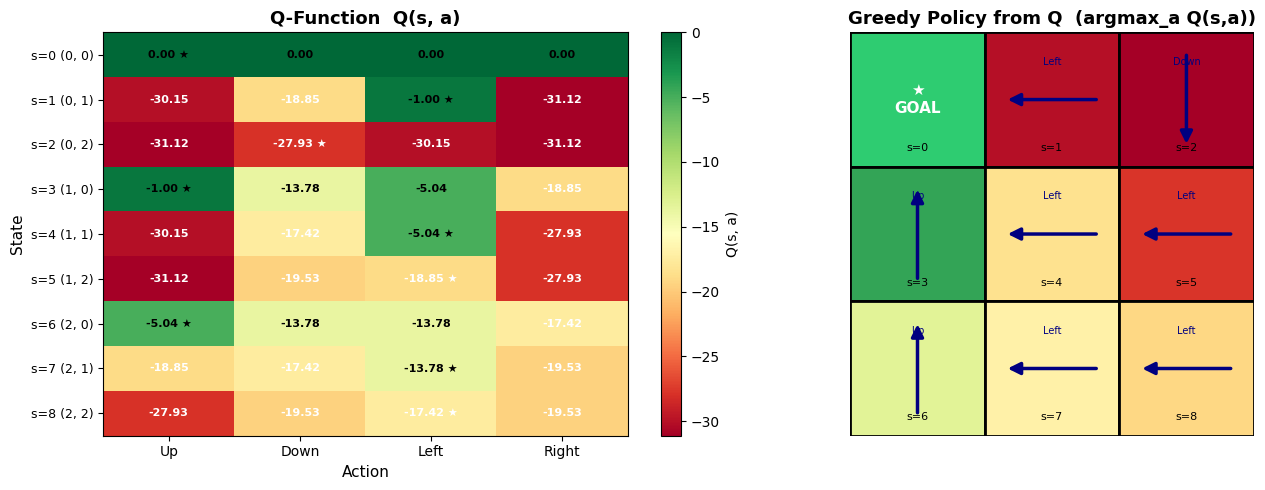

Best action per state (greedy policy from Q):
 State   (r,c)   Best action     Q(s,a*)
-------------------------------------------------------
  s=0    (0, 0)            Up      0.0000
  s=1    (0, 1)          Left     -1.0000
  s=2    (0, 2)          Down    -27.9344
  s=3    (1, 0)            Up     -1.0000
  s=4    (1, 1)          Left     -5.0382
  s=5    (1, 2)          Left    -18.8514
  s=6    (2, 0)            Up     -5.0382
  s=7    (2, 1)          Left    -13.7773
  s=8    (2, 2)          Left    -17.4184


In [17]:
# ── Plot 1: Q heatmap (states × actions) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
im = ax.imshow(Q, cmap='RdYlGn', aspect='auto')
ax.set_title("Q-Function  Q(s, a)", fontsize=13, fontweight='bold')
ax.set_xlabel("Action", fontsize=11)
ax.set_ylabel("State", fontsize=11)
ax.set_xticks(range(len(ACTIONS)))
ax.set_xticklabels(ACTION_NAMES, fontsize=10)
ax.set_yticks(range(NUM_STATES))
ax.set_yticklabels([f"s={s} {state_to_rc(s)}" for s in range(NUM_STATES)], fontsize=9)
plt.colorbar(im, ax=ax, label='Q(s, a)')

vmin, vmax = Q.min(), Q.max()
for s in range(NUM_STATES):
    for a in ACTIONS:
        val = Q[s, a]
        color = 'white' if val < (vmin + vmax) / 2 else 'black'
        # mark the best action per state with a star
        star = " ★" if a == np.argmax(Q[s]) else ""
        ax.text(a, s, f"{val:.2f}{star}",
                ha='center', va='center', fontsize=8,
                color=color, fontweight='bold')

# ── Plot 2: greedy policy arrows on grid ─────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, GRID_W)
ax.set_ylim(0, GRID_H)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Greedy Policy from Q  (argmax_a Q(s,a))", fontsize=13, fontweight='bold')

# arrow direction vectors in plot coordinates (col, row_plot)
ARROW_DC = [ 0,  0, -1,  1]   # col shift: Up, Down, Left, Right
ARROW_DR = [ 1, -1,  0,  0]   # row_plot shift (flipped): Up=+1, Down=-1

for s in range(NUM_STATES):
    r, c = state_to_rc(s)
    row_plot = GRID_H - 1 - r
    cx, cy = c + 0.5, row_plot + 0.5

    # cell background
    if s == GOAL_STATE:
        color = '#2ecc71'
    else:
        # shade by V value
        norm_v = (V_q[s] - V_q.min()) / (V_q.max() - V_q.min() + 1e-9)
        color = plt.cm.RdYlGn(norm_v)
    rect = plt.Rectangle((c, row_plot), 1, 1,
                          linewidth=2, edgecolor='black', facecolor=color)
    ax.add_patch(rect)
    ax.text(c + 0.5, row_plot + 0.1, f"s={s}", ha='center',
            va='bottom', fontsize=8, color='black')

    if s == GOAL_STATE:
        ax.text(cx, cy, "★\nGOAL", ha='center', va='center',
                fontsize=11, fontweight='bold', color='white')
        continue

    best_a = int(np.argmax(Q[s]))
    dx = ARROW_DC[best_a] * 0.35
    dy = ARROW_DR[best_a] * 0.35

    # draw arrow only if action actually moves the agent
    ns, _ = step(s, best_a)
    arrow_color = 'navy' if ns != s else 'gray'
    ax.annotate("", xy=(cx + dx, cy + dy), xytext=(cx - dx, cy - dy),
                arrowprops=dict(arrowstyle="-|>", color=arrow_color,
                                lw=2.5, mutation_scale=18))
    ax.text(cx, cy + 0.28, ACTION_NAMES[best_a],
            ha='center', va='center', fontsize=7, color=arrow_color)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("Best action per state (greedy policy from Q):")
print("=" * 55)
print(f"{'State':>6}  {'(r,c)':>6}  {'Best action':>12}  {'Q(s,a*)':>10}")
print("-" * 55)
for s in range(NUM_STATES):
    best_a = int(np.argmax(Q[s]))
    print(f"  s={s}    {str(state_to_rc(s)):>6}  "
          f"{ACTION_NAMES[best_a]:>12}  {Q[s, best_a]:>10.4f}")

### Learning Curves: Convergence of V and Q

We visualize how the value function and Q-function evolved during training:

1. **V(s) over iterations** — one line per state, all converging to V*
2. **Q(s, a) over iterations** — one line per (state, action) pair
3. **Max change per iteration** — shows the contraction in action (should decay to 0)

These plots confirm the contraction mapping theorem in practice.

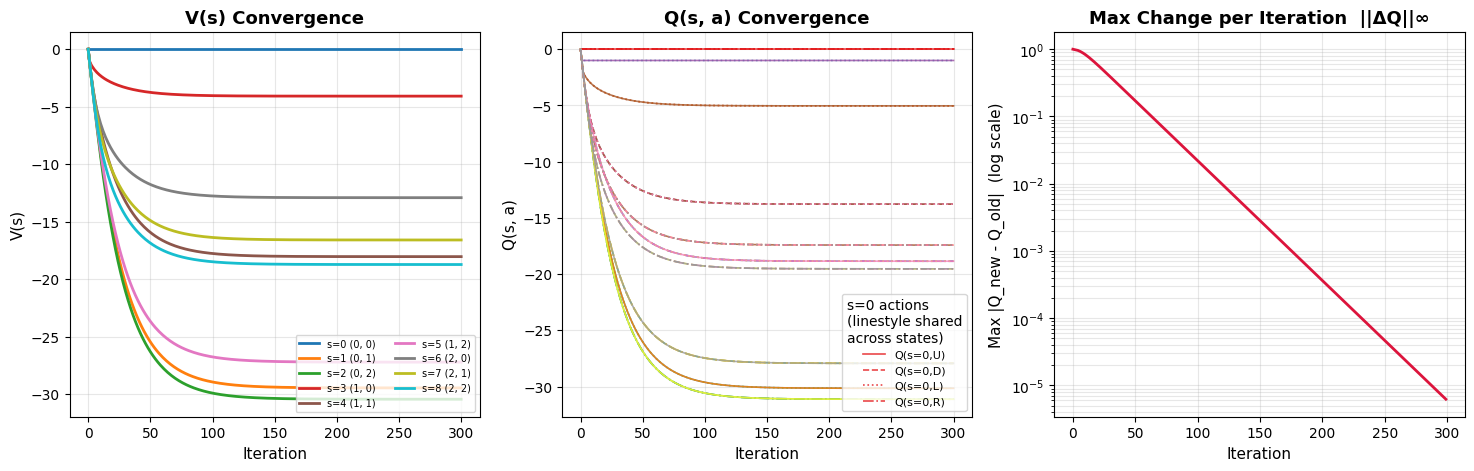

In [15]:
V_history_arr = np.array(V_q_history)   # shape: (NUM_ITER+1, NUM_STATES)
Q_history_arr = np.array(Q_history)     # shape: (NUM_ITER+1, NUM_STATES, NUM_ACTIONS)
iters = np.arange(len(V_history_arr))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: V(s) convergence ──────────────────────────────────────────────────
ax = axes[0]
colors_v = plt.cm.tab10(np.linspace(0, 1, NUM_STATES))
for s in range(NUM_STATES):
    ax.plot(iters, V_history_arr[:, s],
            color=colors_v[s], linewidth=2,
            label=f"s={s} {state_to_rc(s)}")
ax.set_title("V(s) Convergence", fontsize=13, fontweight='bold')
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("V(s)", fontsize=11)
ax.legend(fontsize=7, ncol=2, loc='lower right')
ax.grid(True, alpha=0.3)

# ── Plot 2: Q(s,a) convergence ────────────────────────────────────────────────
ax = axes[1]
linestyles = ['-', '--', ':', '-.']
colors_q = plt.cm.Set1(np.linspace(0, 1, NUM_STATES))
for s in range(NUM_STATES):
    for a in ACTIONS:
        ax.plot(iters, Q_history_arr[:, s, a],
                color=colors_q[s], linewidth=1.2,
                linestyle=linestyles[a],
                alpha=0.8,
                label=f"Q(s={s},{ACTION_NAMES[a][0]})" if s == 0 else None)
ax.set_title("Q(s, a) Convergence", fontsize=13, fontweight='bold')
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("Q(s, a)", fontsize=11)
ax.legend(fontsize=8, loc='lower right',
          title="s=0 actions\n(linestyle shared\nacross states)")
ax.grid(True, alpha=0.3)

# ── Plot 3: max change (convergence metric) ───────────────────────────────────
ax = axes[2]
ax.semilogy(conv_q, color='crimson', linewidth=2)
ax.set_title("Max Change per Iteration  ||ΔQ||∞", fontsize=13, fontweight='bold')
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("Max |Q_new - Q_old|  (log scale)", fontsize=11)
ax.grid(True, alpha=0.3, which='both')

# mark where change drops below thr

### Policy Evaluation: All Non-Goal Starting Positions

We test the greedy policy derived from Q on **all 8 non-goal starting states**.

For each starting state we run one episode and visualize the trajectory.
This exhaustively confirms that the policy finds a path to the goal
from every possible position on the grid.

Greedy policy derived from Q:
 State   (r,c)   Best action
-----------------------------------
  s=0    (0, 0)            Up
  s=1    (0, 1)          Left
  s=2    (0, 2)          Down
  s=3    (1, 0)            Up
  s=4    (1, 1)          Left
  s=5    (1, 2)          Left
  s=6    (2, 0)            Up
  s=7    (2, 1)          Left
  s=8    (2, 2)          Left


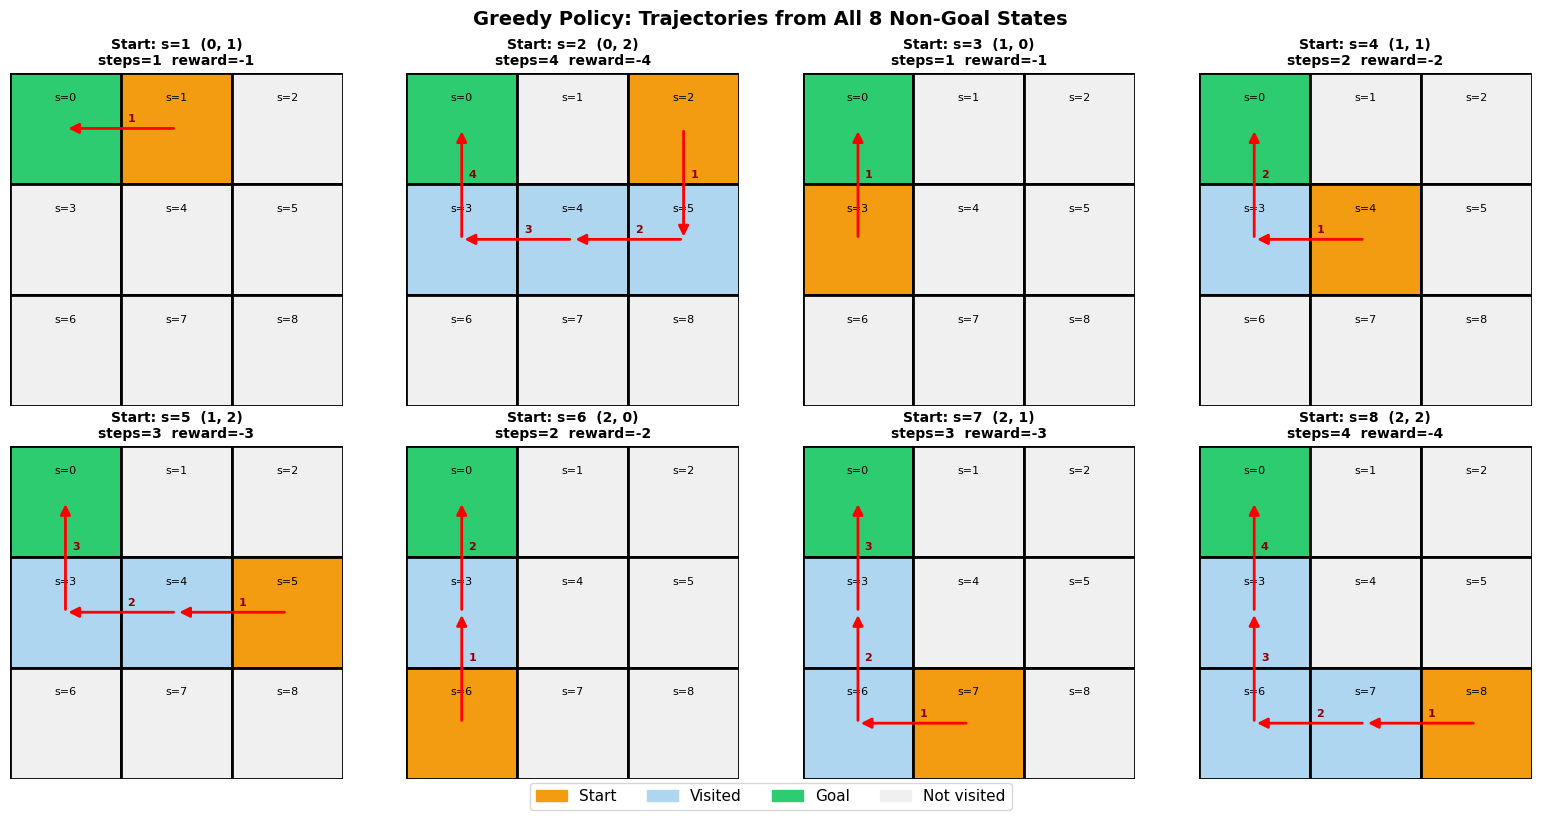


Episode summary:
 Start     (r,c)   Steps    Reward
---------------------------------------------
  s=1    (0, 1)       1        -1  ✓ optimal
  s=2    (0, 2)       4        -4
  s=3    (1, 0)       1        -1  ✓ optimal
  s=4    (1, 1)       2        -2  ✓ optimal
  s=5    (1, 2)       3        -3  ✓ optimal
  s=6    (2, 0)       2        -2  ✓ optimal
  s=7    (2, 1)       3        -3  ✓ optimal
  s=8    (2, 2)       4        -4  ✓ optimal
---------------------------------------------
  Average steps: 2.50
  Max steps:     4

✓ Greedy policy reaches goal from all 8 starting states


In [20]:
# ── Build greedy policy from Q ────────────────────────────────────────────────
GreedyPolicy = np.zeros((NUM_STATES, len(ACTIONS)))
for s in range(NUM_STATES):
    best_a = int(np.argmax(Q[s]))
    GreedyPolicy[s, best_a] = 1.0
GreedyPolicy[GOAL_STATE] = np.array([1.0, 0.0, 0.0, 0.0])

print("Greedy policy derived from Q:")
print(f"{'State':>6}  {'(r,c)':>6}  {'Best action':>12}")
print("-" * 35)
for s in range(NUM_STATES):
    best_a = int(np.argmax(GreedyPolicy[s]))
    print(f"  s={s}    {str(state_to_rc(s)):>6}  {ACTION_NAMES[best_a]:>12}")

# ── Run one episode per non-goal state ───────────────────────────────────────
non_goal_states = [s for s in range(NUM_STATES) if s != GOAL_STATE]  # 1..8

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

episode_stats = []

for idx, start in enumerate(non_goal_states):
    sh, rh = run_episode(start, GreedyPolicy)
    episode_stats.append((start, len(sh) - 1, sum(rh)))

    ax = axes[idx]
    ax.set_xlim(0, GRID_W)
    ax.set_ylim(0, GRID_H)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"Start: s={start}  {state_to_rc(start)}\n"
                 f"steps={len(sh)-1}  reward={sum(rh):.0f}",
                 fontsize=10, fontweight='bold')

    # draw cells
    for s in range(NUM_STATES):
        r, c = state_to_rc(s)
        rp = GRID_H - 1 - r
        if s == GOAL_STATE:
            color = '#2ecc71'
        elif s == start:
            color = '#f39c12'
        elif s in sh:
            color = '#aed6f1'
        else:
            color = '#f0f0f0'
        rect = plt.Rectangle((c, rp), 1, 1,
                              linewidth=2, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        ax.text(c + 0.5, rp + 0.78, f"s={s}",
                ha='center', va='center', fontsize=8)

    # draw trajectory arrows with step numbers
    for i in range(len(sh) - 1):
        s0, s1 = sh[i], sh[i + 1]
        r0, c0 = state_to_rc(s0)
        r1, c1 = state_to_rc(s1)
        x0, y0 = c0 + 0.5, GRID_H - 1 - r0 + 0.5
        x1, y1 = c1 + 0.5, GRID_H - 1 - r1 + 0.5
        if (x0, y0) != (x1, y1):
            ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle="-|>", color='red',
                                        lw=2, mutation_scale=15))
        ax.text((x0 + x1) / 2 + 0.06, (y0 + y1) / 2 + 0.06,
                str(i + 1), fontsize=8, color='darkred', fontweight='bold')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color='#f39c12', label='Start'),
    mpatches.Patch(color='#aed6f1', label='Visited'),
    mpatches.Patch(color='#2ecc71', label='Goal'),
    mpatches.Patch(color='#f0f0f0', label='Not visited'),
]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=4, fontsize=11, frameon=True,
           bbox_to_anchor=(0.5, -0.03))

plt.suptitle("Greedy Policy: Trajectories from All 8 Non-Goal States",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\nEpisode summary:")
print("=" * 45)
print(f"{'Start':>6}  {'(r,c)':>8}  {'Steps':>6}  {'Reward':>8}")
print("-" * 45)
for start, steps, reward in episode_stats:
    opt = "  ✓ optimal" if steps == sum(state_to_rc(start)) else ""
    print(f"  s={start}    {str(state_to_rc(start)):>6}  {steps:>6}  "
          f"{reward:>8.0f}{opt}")
print("-" * 45)
print(f"  Average steps: {np.mean([s for _,s,_ in episode_stats]):.2f}")
print(f"  Max steps:     {max(s for _,s,_ in episode_stats)}")
print("\n✓ Greedy policy reaches goal from all 8 starting states")

### Policy Improvement: Soft Update Towards Greedy Policy

The current policy was initialized randomly and may be suboptimal
(as seen in the trajectory above — the agent takes unnecessary detours).

We improve it using a **soft policy update**:

$$\pi_{\text{new}}(a|s) = (1 - \tau) \cdot \pi_{\text{old}}(a|s) + \tau \cdot \pi_{\text{target}}(a|s)$$

where:
- $\pi_{\text{target}}(a|s)$ = **greedy policy** — puts probability 1 on $\arg\max_a Q(s,a)$
- $\tau \in (0, 1)$ = **step size** (small $\tau$ → slow but stable update)

We then re-run Q-iteration under the new policy and repeat.
After several rounds the policy converges to the optimal one.

Policy improvement  |  τ=0.3  |  20 rounds  |  300 Q-iters per round
Round  1  |  Q conv=6.25e-06  |  avg steps=46.38  |  max steps=110
Round  2  |  Q conv=0.00e+00  |  avg steps=5.62  |  max steps=11
Round  3  |  Q conv=0.00e+00  |  avg steps=2.88  |  max steps=6
Round  4  |  Q conv=0.00e+00  |  avg steps=3.25  |  max steps=6
Round  5  |  Q conv=0.00e+00  |  avg steps=3.25  |  max steps=9
Round  6  |  Q conv=0.00e+00  |  avg steps=2.88  |  max steps=5
Round  7  |  Q conv=0.00e+00  |  avg steps=2.50  |  max steps=4
Round  8  |  Q conv=0.00e+00  |  avg steps=2.38  |  max steps=4
Round  9  |  Q conv=0.00e+00  |  avg steps=2.25  |  max steps=4
Round 10  |  Q conv=0.00e+00  |  avg steps=2.38  |  max steps=4
Round 11  |  Q conv=0.00e+00  |  avg steps=2.38  |  max steps=5
Round 12  |  Q conv=0.00e+00  |  avg steps=2.25  |  max steps=4
Round 13  |  Q conv=0.00e+00  |  avg steps=2.25  |  max steps=4
Round 14  |  Q conv=0.00e+00  |  avg steps=2.25  |  max steps=4
Round 15  |  Q conv=0.00e+00  |

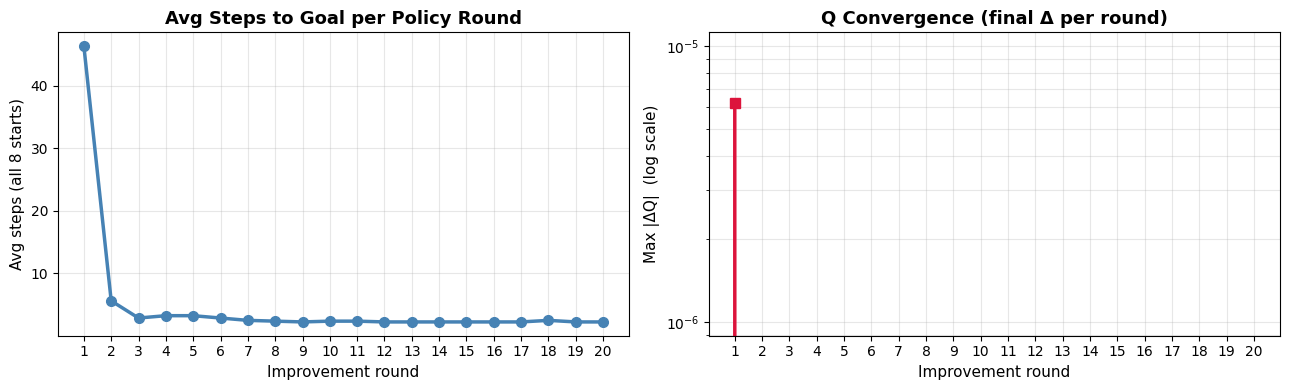


Final policy after improvement:
 State   (r,c)   Best action   probability
--------------------------------------------------
  s=0    (0, 0)            Up       1.0000
  s=1    (0, 1)          Left       0.9992
  s=2    (0, 2)          Left       0.9989
  s=3    (1, 0)            Up       0.9998
  s=4    (1, 1)          Left       0.9994
  s=5    (1, 2)          Left       0.9993
  s=6    (2, 0)            Up       0.9994
  s=7    (2, 1)          Left       0.9996
  s=8    (2, 2)          Left       0.9995


In [48]:
def make_greedy_policy(Q):
    """Target policy: probability 1 on argmax_a Q(s,a)."""
    pi = np.zeros((NUM_STATES, len(ACTIONS)))
    for s in range(NUM_STATES):
        pi[s, int(np.argmax(Q[s]))] = 1.0
    pi[GOAL_STATE] = np.array([1.0, 0.0, 0.0, 0.0])
    return pi


def soft_policy_update(policy, Q, tau=0.1):
    """
    Soft update: π_new = (1 - τ) · π_old + τ · π_target

    Args:
        policy : current policy  (NUM_STATES × NUM_ACTIONS)
        Q      : current Q-function
        tau    : step size (small = conservative update)

    Returns:
        updated policy (rows sum to 1)
    """
    pi_target = make_greedy_policy(Q)
    pi_new = (1 - tau) * policy + tau * pi_target
    # goal state always fixed
    pi_new[GOAL_STATE] = np.array([1.0, 0.0, 0.0, 0.0])
    return pi_new


# ── Hyperparameters ───────────────────────────────────────────────────────────
TAU          = 0.3    # soft update step size
NUM_ROUNDS   = 20     # policy improvement rounds
NUM_ITER_PI  = 300    # Q-iterations per round
gamma        = 0.99

# ── Initialize from the random policy we built in Cell 2 ─────────────────────
current_policy = Policy.copy()
V_pi = np.zeros(NUM_STATES)
Q_pi = np.zeros((NUM_STATES, len(ACTIONS)))

# tracking across rounds
round_conv      = []   # final max_change per round
round_avg_steps = []   # average steps to goal (all 8 starts) per round
round_policies  = [current_policy.copy()]
round_Q         = []

print(f"Policy improvement  |  τ={TAU}  |  {NUM_ROUNDS} rounds  "
      f"|  {NUM_ITER_PI} Q-iters per round")
print("=" * 70)

for rnd in range(NUM_ROUNDS):
    # ── rebuild transition matrix for current policy ──────────────────────────
    P_pi = build_transition_matrix(current_policy)

    # ── run Q-iteration ───────────────────────────────────────────────────────
    for it in range(NUM_ITER_PI):
        V_pi, Q_pi, delta = q_iteration_step(
            V_pi, Q_pi, P_action, current_policy, Rewards, gamma)
    round_conv.append(delta)
    round_Q.append(Q_pi.copy())

    # ── evaluate: avg steps from all 8 non-goal starts ───────────────────────
    steps_list = []
    for start in non_goal_states:
        sh, _ = run_episode(start, current_policy)
        steps_list.append(len(sh) - 1)
    avg_steps = np.mean(steps_list)
    round_avg_steps.append(avg_steps)

    print(f"Round {rnd+1:2d}  |  Q conv={delta:.2e}  |  "
          f"avg steps={avg_steps:.2f}  |  "
          f"max steps={max(steps_list)}")

    # ── soft policy update ────────────────────────────────────────────────────
    current_policy = soft_policy_update(current_policy, Q_pi, tau=TAU)
    round_policies.append(current_policy.copy())

print("=" * 70)
print("✓ Policy improvement complete")

# ── Visualize improvement progress ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(range(1, NUM_ROUNDS + 1), round_avg_steps,
        'o-', color='steelblue', linewidth=2.5, markersize=7)
ax.set_title("Avg Steps to Goal per Policy Round", fontsize=13, fontweight='bold')
ax.set_xlabel("Improvement round", fontsize=11)
ax.set_ylabel("Avg steps (all 8 starts)", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, NUM_ROUNDS + 1))

ax = axes[1]
ax.semilogy(range(1, NUM_ROUNDS + 1), round_conv,
            's-', color='crimson', linewidth=2.5, markersize=7)
ax.set_title("Q Convergence (final Δ per round)", fontsize=13, fontweight='bold')
ax.set_xlabel("Improvement round", fontsize=11)
ax.set_ylabel("Max |ΔQ|  (log scale)", fontsize=11)
ax.grid(True, alpha=0.3, which='both')
ax.set_xticks(range(1, NUM_ROUNDS + 1))

plt.tight_layout()
plt.show()

# ── Final policy summary ──────────────────────────────────────────────────────
print("\nFinal policy after improvement:")
print(f"{'State':>6}  {'(r,c)':>6}  {'Best action':>12}  {'probability':>12}")
print("-" * 50)
for s in range(NUM_STATES):
    best_a = int(np.argmax(current_policy[s]))
    print(f"  s={s}    {str(state_to_rc(s)):>6}  "
          f"{ACTION_NAMES[best_a]:>12}  {current_policy[s, best_a]:>11.4f}")

### Final Policy: Trajectories from All 8 Starting States

After policy improvement, we re-run episodes from all 8 non-goal states
using the updated policy and compare with the original random policy.

We expect:
- **Shorter paths** — no unnecessary detours
- **Direct routes** — agent moves straight towards the goal
- The path length from state s=(r,c) should ideally equal r+c steps
  (Manhattan distance to the goal at s=0)

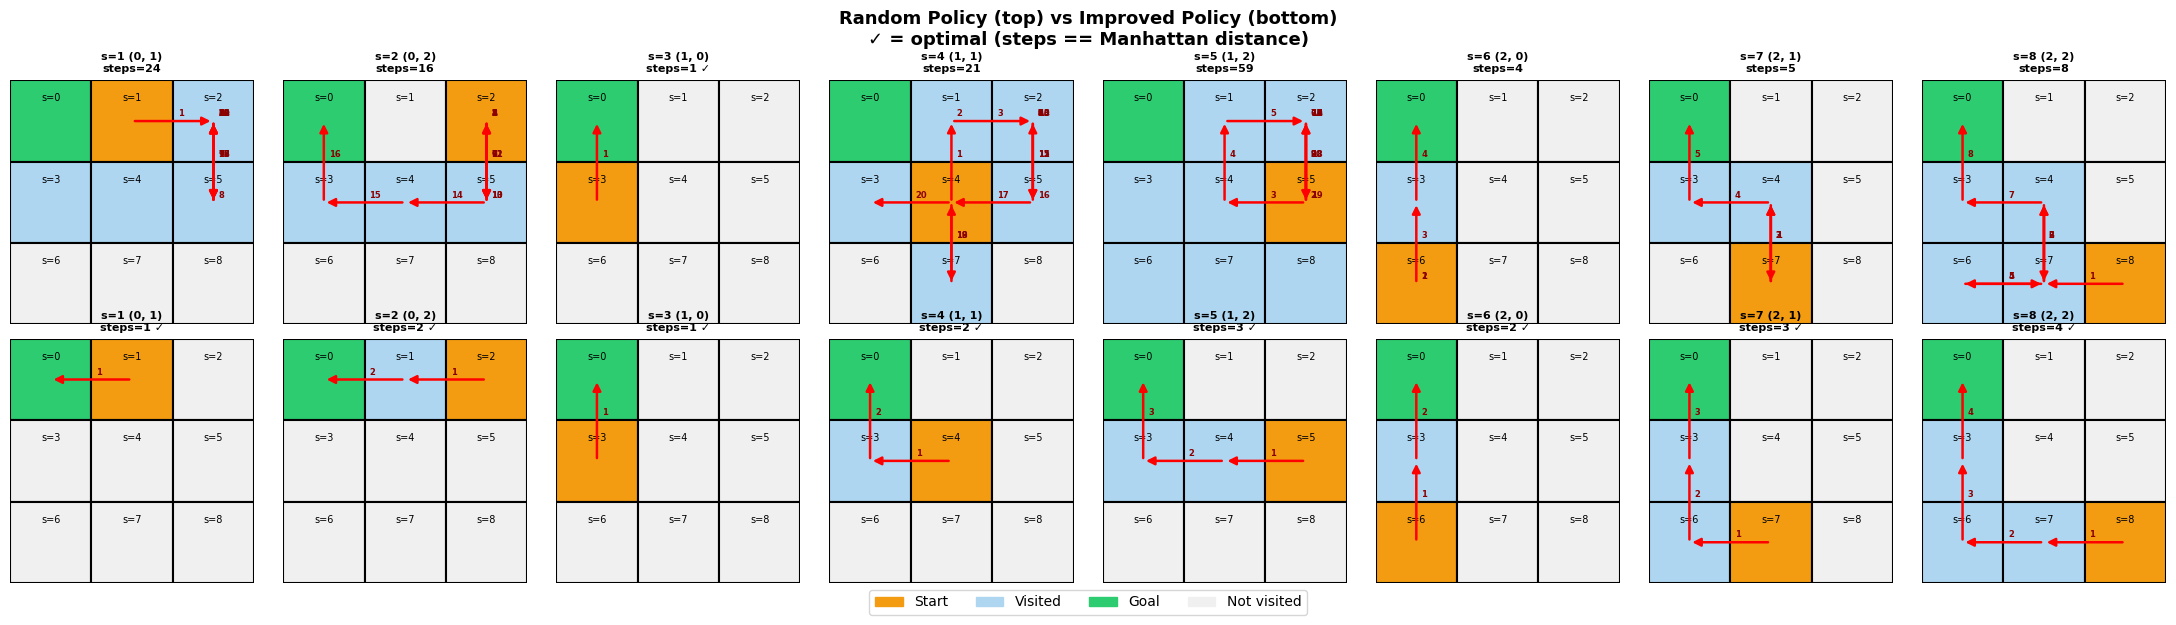

Steps comparison: Random vs Improved policy
 State   (r,c)   Manhattan    Random    Improved    Saved
-----------------------------------------------------------------
  s=1    (0, 1)           1        24          1 ✓       23
  s=2    (0, 2)           2        16          2 ✓       14
  s=3    (1, 0)           1         1          1 ✓        0
  s=4    (1, 1)           2        21          2 ✓       19
  s=5    (1, 2)           3        59          3 ✓       56
  s=6    (2, 0)           2         4          2 ✓        2
  s=7    (2, 1)           3         5          3 ✓        2
  s=8    (2, 2)           4         8          4 ✓        4
-----------------------------------------------------------------
               Total                    138          18      120

  Steps saved by improvement: 120 (87.0%)

✓ Improved policy is shorter or equal on all starting states


In [49]:
# ── Run episodes under ORIGINAL random policy and FINAL improved policy ───────
fig, axes = plt.subplots(2, 8, figsize=(22, 6))

policies_to_show = [
    (Policy,         "Random policy",   0),
    (current_policy, "Improved policy", 1),
]

all_stats = {}

for pi, pi_name, row in policies_to_show:
    stats = []
    for idx, start in enumerate(non_goal_states):
        sh, rh = run_episode(start, pi, max_steps=500)
        stats.append((start, len(sh) - 1, sum(rh)))

        ax = axes[row, idx]
        ax.set_xlim(0, GRID_W)
        ax.set_ylim(0, GRID_H)
        ax.set_aspect('equal')
        ax.axis('off')

        # row label only on first column
        if idx == 0:
            ax.set_ylabel(pi_name, fontsize=9, fontweight='bold')

        manhattan = sum(state_to_rc(start))
        opt_mark  = " ✓" if len(sh) - 1 == manhattan else ""
        ax.set_title(f"s={start} {state_to_rc(start)}\n"
                     f"steps={len(sh)-1}{opt_mark}",
                     fontsize=8, fontweight='bold')

        # draw cells
        for s in range(NUM_STATES):
            r, c = state_to_rc(s)
            rp = GRID_H - 1 - r
            if s == GOAL_STATE:
                color = '#2ecc71'
            elif s == start:
                color = '#f39c12'
            elif s in sh:
                color = '#aed6f1'
            else:
                color = '#f0f0f0'
            rect = plt.Rectangle((c, rp), 1, 1,
                                  linewidth=1.5, edgecolor='black', facecolor=color)
            ax.add_patch(rect)
            ax.text(c + 0.5, rp + 0.78, f"s={s}",
                    ha='center', va='center', fontsize=7)

        # draw arrows
        for i in range(min(len(sh) - 1, 20)):   # cap at 20 arrows for readability
            s0, s1 = sh[i], sh[i + 1]
            r0, c0 = state_to_rc(s0)
            r1, c1 = state_to_rc(s1)
            x0, y0 = c0 + 0.5, GRID_H - 1 - r0 + 0.5
            x1, y1 = c1 + 0.5, GRID_H - 1 - r1 + 0.5
            if (x0, y0) != (x1, y1):
                ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                            arrowprops=dict(arrowstyle="-|>",
                                            color='red', lw=1.8,
                                            mutation_scale=12))
            ax.text((x0+x1)/2 + 0.06, (y0+y1)/2 + 0.06,
                    str(i+1), fontsize=6, color='darkred', fontweight='bold')

    all_stats[pi_name] = stats

# legend
legend_patches = [
    mpatches.Patch(color='#f39c12', label='Start'),
    mpatches.Patch(color='#aed6f1', label='Visited'),
    mpatches.Patch(color='#2ecc71', label='Goal'),
    mpatches.Patch(color='#f0f0f0', label='Not visited'),
]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=4, fontsize=10, frameon=True,
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle("Random Policy (top) vs Improved Policy (bottom)\n"
             "✓ = optimal (steps == Manhattan distance)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Comparison table ──────────────────────────────────────────────────────────
print("Steps comparison: Random vs Improved policy")
print("=" * 65)
print(f"{'State':>6}  {'(r,c)':>6}  {'Manhattan':>10}  "
      f"{'Random':>8}  {'Improved':>10}  {'Saved':>7}")
print("-" * 65)

total_random   = 0
total_improved = 0

for i, start in enumerate(non_goal_states):
    manhattan = sum(state_to_rc(start))
    steps_rnd = all_stats["Random policy"][i][1]
    steps_imp = all_stats["Improved policy"][i][1]
    saved     = steps_rnd - steps_imp
    total_random   += steps_rnd
    total_improved += steps_imp
    opt = " ✓" if steps_imp == manhattan else ""
    print(f"  s={start}    {str(state_to_rc(start)):>6}  {manhattan:>10}  "
          f"{steps_rnd:>8}  {steps_imp:>9}{opt}  {saved:>7}")

print("-" * 65)
print(f"  {'Total':>18}               "
      f"{total_random:>8}  {total_improved:>10}  {total_random-total_improved:>7}")
print(f"\n  Steps saved by improvement: "
      f"{total_random - total_improved} "
      f"({(total_random-total_improved)/total_random*100:.1f}%)")
print("\n✓ Improved policy is shorter or equal on all starting states")